# Customer Churn Prediction Analysis

### End-to-End Data Analysis and Machine Learning Project

**Objective:**  
Analyze customer churn patterns, identify key factors associated with churn, and build a machine learning model to predict customers at risk of churning.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## 1. Project Overview

Customer churn is a major business challenge for subscription-based companies. 
This project analyzes customer demographics, services, contract information, 
payment methods, tenure, and billing characteristics to identify patterns 
associated with customer churn.

### Business Questions

- What percentage of customers churn?
- Which customer segments have the highest churn rates?
- How do contract type and tenure relate to churn?
- Which payment and internet-service categories have higher churn?
- Which factors are most strongly associated with churn?
- Can machine learning predict customers who are likely to churn?

## 2. Data Loading and Initial Inspection

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [18]:
df.shape

(7043, 21)

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [21]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [22]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [23]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [24]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [25]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df["customerID"].duplicated().sum()

np.int64(0)

## 3. Data Cleaning

In [28]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
20.25     6
20.45     5
20.3      5
74.7      4
70.6      4
44        4
75.3      4
20.4      4
19.85     4
49.9      4
Name: count, dtype: int64

In [29]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [30]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [31]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- customerID ---
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

--- gender ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

--- Partner ---
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- Dependents ---
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- PhoneService ---
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- MultipleLines ---
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

--- InternetService ---
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

--- OnlineSecurity ---
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

--- OnlineBackup ---
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: s

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\2079242338.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [32]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [33]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [34]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


In [35]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [36]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [37]:
df[df["tenure"] == 0][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,0.0,Two year,No
753,3115-CZMZD,0,20.25,0.0,Two year,No
936,5709-LVOEQ,0,80.85,0.0,Two year,No
1082,4367-NUYAO,0,25.75,0.0,Two year,No
1340,1371-DWPAZ,0,56.05,0.0,Two year,No
3331,7644-OMVMY,0,19.85,0.0,Two year,No
3826,3213-VVOLG,0,25.35,0.0,Two year,No
4380,2520-SGTTA,0,20.00,0.0,Two year,No
5218,2923-ARZLG,0,19.70,0.0,One year,No
6670,4075-WKNIU,0,73.35,0.0,Two year,No


In [38]:
df.shape

(7043, 21)

In [39]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [40]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Rows: 7043
Columns: 21
Missing values: 0
Duplicate rows: 0
Duplicate customer IDs: 0


## 4. Exploratory Data Analysis

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

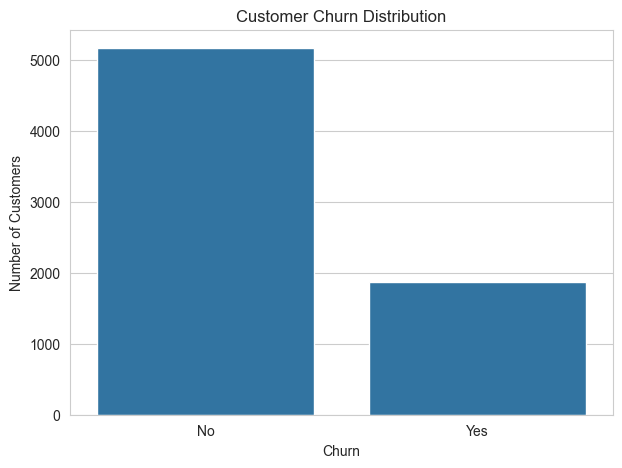

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

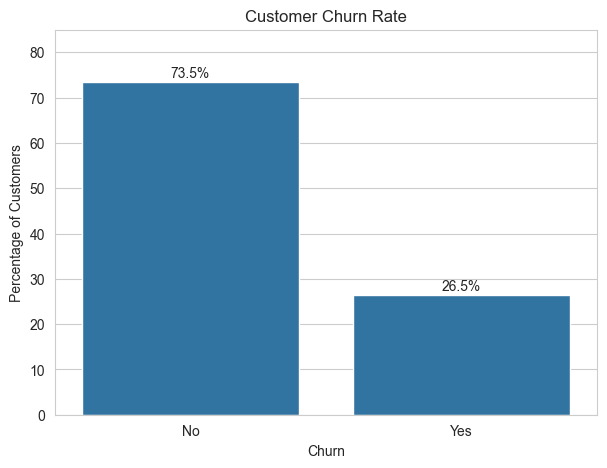

In [43]:
churn_pct = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=churn_pct.index,
    y=churn_pct.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")

for i, value in enumerate(churn_pct.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 85)

plt.show()

In [44]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


### Initial Business Findings

- The dataset contains 7,043 customers.
- 1,869 customers have churned.
- The overall churn rate is approximately 26.5%.
- Customer churn represents a significant retention challenge and requires further segmentation analysis.

In [45]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [46]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

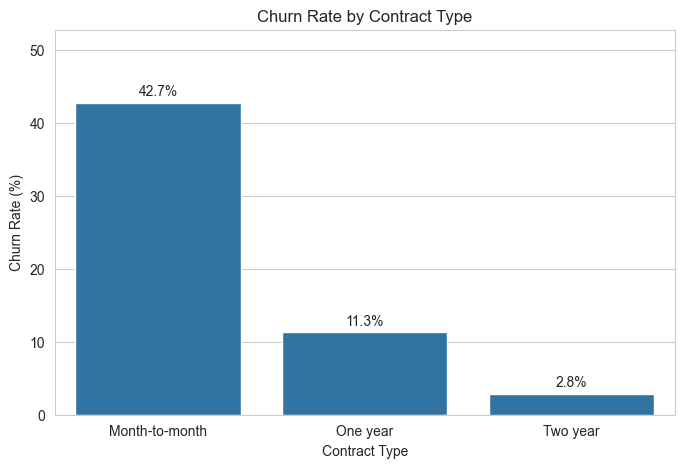

In [47]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(contract_churn_rate.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, max(contract_churn_rate.values) + 10)

plt.show()

In [48]:
contract_summary = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_summary


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


### Contract Analysis

- Month-to-month customers have the highest churn rate at 42.7%.
- One-year contract customers have an 11.3% churn rate.
- Two-year contract customers have the lowest churn rate at 2.8%.
- Contract type shows a strong association with customer churn.
- Month-to-month customers should be considered a priority segment for retention analysis.

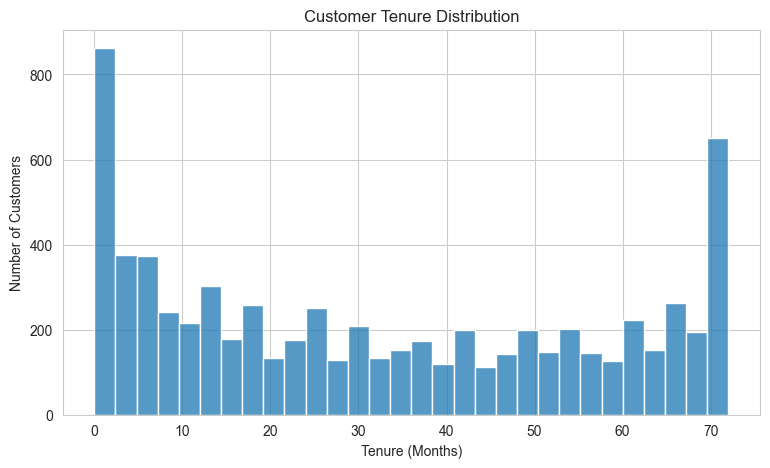

In [49]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [50]:
bins = [0, 12, 24, 48, 72]
labels = ["0–12 months", "13–24 months", "25–48 months", "49–72 months"]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [51]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn_rate

TenureGroup
0–12 months     47.438243
13–24 months    28.710938
25–48 months    20.388959
49–72 months     9.513176
Name: Churn, dtype: float64

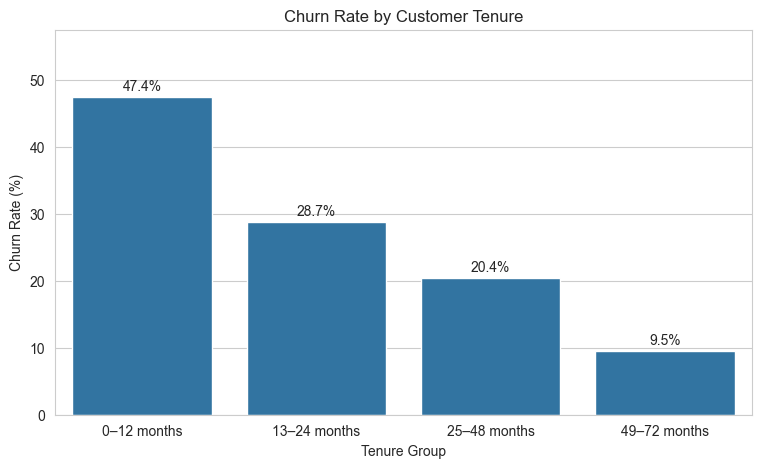

In [52]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_churn_rate.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, max(tenure_churn_rate.values) + 10)

plt.show()

In [53]:
tenure_summary = pd.crosstab(
    df["TenureGroup"],
    df["Churn"]
)

tenure_summary

Churn,No,Yes
TenureGroup,,
0–12 months,1149,1037
13–24 months,730,294
25–48 months,1269,325
49–72 months,2026,213


### Tenure Analysis

- Customers with 0–12 months of tenure have the highest churn rate at 47.4%.
- Churn declines consistently as customer tenure increases.
- Customers with 49–72 months of tenure have the lowest churn rate at 9.5%.
- The early customer lifecycle represents the highest-risk period for churn.
- Retention efforts should therefore place particular emphasis on customers during their first 12 months.

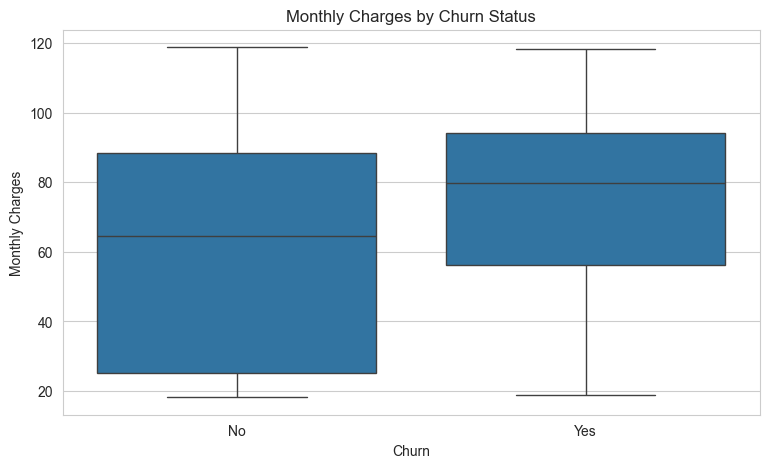

In [54]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [55]:
monthly_charges_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

monthly_charges_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


### Monthly Charges Analysis

- Customers who churned have higher average monthly charges than customers who stayed.
- Average monthly charges were $74.44 for churned customers versus $61.27 for retained customers.
- Median monthly charges were also higher among churned customers ($79.65 vs. $64.43).
- Monthly charges are associated with churn, but the distributions overlap substantially, indicating that charges alone are not sufficient to explain churn.

In [56]:
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

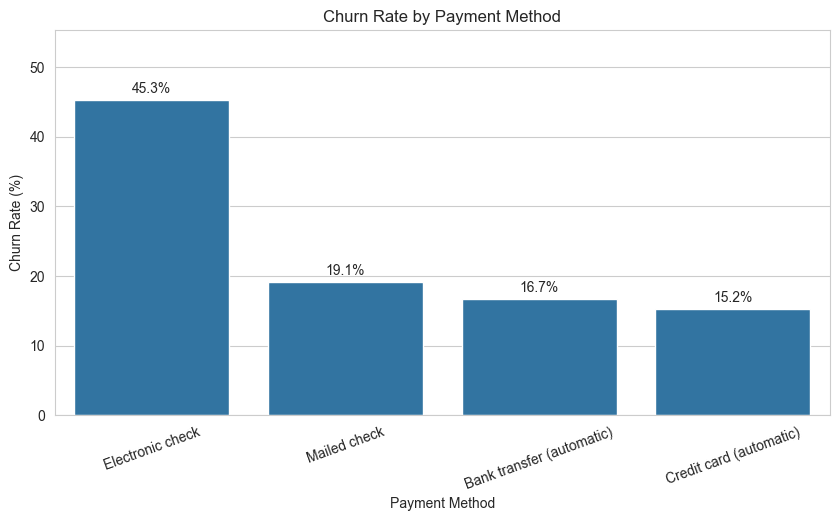

In [57]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

for i, value in enumerate(payment_churn_rate.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, max(payment_churn_rate.values) + 10)

plt.show()

In [58]:
payment_summary = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_summary

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


### Payment Method Analysis

- Electronic check customers have the highest churn rate at 45.3%.
- Mailed check customers have a churn rate of 19.1%.
- Bank transfer and credit card automatic-payment customers have lower churn rates of 16.7% and 15.2%.
- Electronic-check customers represent a high-risk segment that warrants further investigation.
- The relationship between payment method and churn may overlap with other customer characteristics, so it should not be interpreted as a causal relationship.

# Churn by Internet Service

In [59]:
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_churn_rate

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

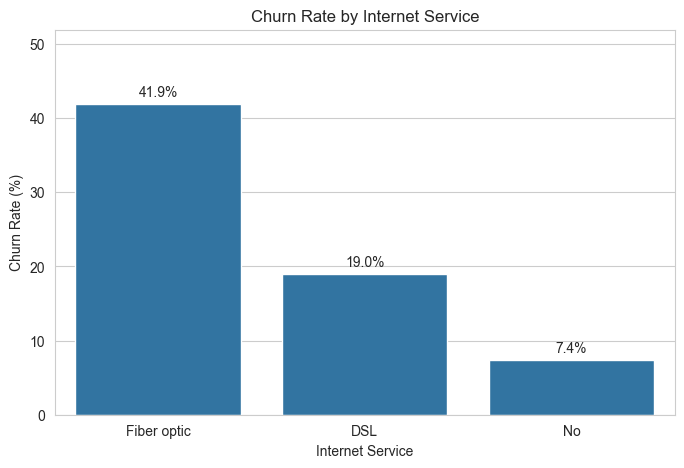

In [60]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(internet_churn_rate.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, max(internet_churn_rate.values) + 10)

plt.show()

In [61]:
internet_summary = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_summary

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


### Internet Service Analysis

- Fiber-optic customers have the highest churn rate at 41.9%.
- DSL customers have a 19.0% churn rate.
- Customers without internet service have the lowest churn rate at 7.4%.
- Fiber-optic customers represent a high-risk segment that requires further investigation.
- The high churn rate may overlap with other factors such as contract type and monthly charges, so this relationship should not be interpreted as causal.

In [62]:
contract_tenure_churn = (
    df.groupby(["TenureGroup", "Contract"], observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

contract_tenure_churn

,TenureGroup,Contract,ChurnRate
0,0–12 months,Month-to-month,51.354062
1,0–12 months,One year,10.483871
2,0–12 months,Two year,0.000000
3,13–24 months,Month-to-month,37.720488
4,13–24 months,One year,8.121827
5,13–24 months,Two year,0.000000
6,25–48 months,Month-to-month,32.917706
7,25–48 months,One year,10.617761
8,25–48 months,Two year,2.189781
9,49–72 months,Month-to-month,26.023392


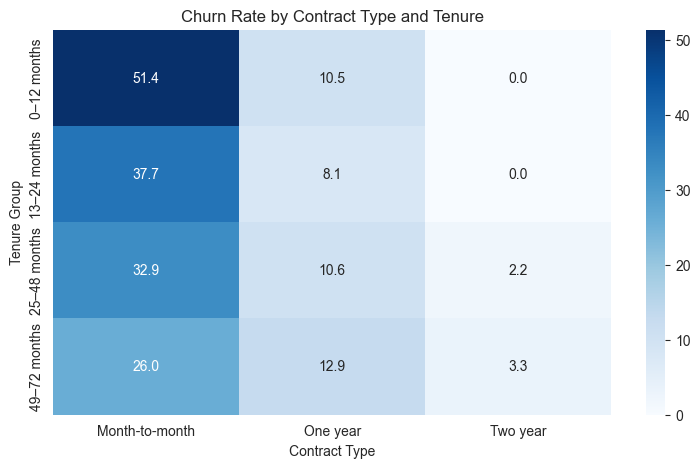

In [63]:
heatmap_data = contract_tenure_churn.pivot(
    index="TenureGroup",
    columns="Contract",
    values="ChurnRate"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Contract Type and Tenure")
plt.xlabel("Contract Type")
plt.ylabel("Tenure Group")

plt.show()

### Contract and Tenure Analysis

- Month-to-month customers have the highest churn rate across every tenure group.
- Customers with 0–12 months of tenure and month-to-month contracts have the highest observed churn rate at 51.4%.
- Month-to-month churn decreases as tenure increases, from 51.4% in the first 12 months to 26.0% among customers with 49–72 months of tenure.
- One-year and two-year contract customers show substantially lower churn rates across tenure groups.
- Long-tenure customers with two-year contracts have the lowest observed churn rate at 3.3%.
- The combination of short tenure and month-to-month contracts represents a high-priority customer retention segment.

## 5. Feature Engineering and Data Preparation

In [64]:
# Check missing values after conversion
df["TotalCharges"].isnull().sum()

np.int64(0)

In [65]:
df["TotalCharges"].dtype

dtype('float64')

In [66]:
# Encode the target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Check the result
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [67]:
df["Churn"].dtype

dtype('int64')

In [68]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Remove customer ID because it has no predictive business meaning
X = X.drop("customerID", axis=1)

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Check the resulting dataset
X.shape

(7043, 33)

In [69]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13–24 months,TenureGroup_25–48 months,TenureGroup_49–72 months
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 33)
Testing set: (1409, 33)


In [71]:
print("Training churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Training churn rate: 0.2653532126375577
Testing churn rate: 0.2654364797728886


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training set:", X_train_scaled.shape)
print("Scaled testing set:", X_test_scaled.shape)

Scaled training set: (5634, 33)
Scaled testing set: (1409, 33)


## 6. Machine Learning Modeling

In [73]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [74]:
# Predict churn on the test data
y_pred = logistic_model.predict(X_test_scaled)

# First 20 predictions
y_pred[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7984
Precision: 0.6500
Recall   : 0.5214
F1-Score : 0.5786


Confusion Matrix:
[[930 105]
 [179 195]]


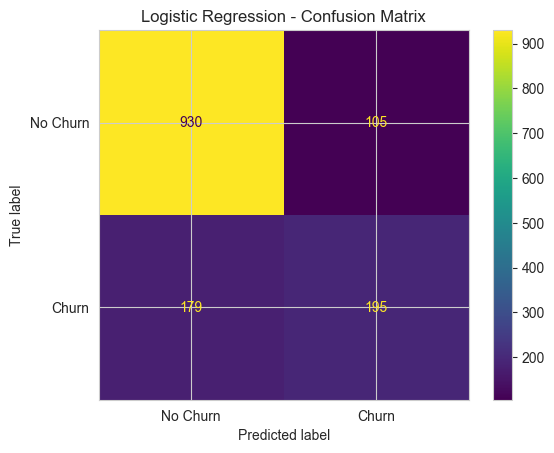

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [77]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [78]:
# Train Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [79]:
# Predict churn using Random Forest

rf_pred = rf_model.predict(X_test)

rf_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [80]:
# Evaluate Random Forest

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Accuracy : 0.7899
Precision: 0.6291
Recall   : 0.5080
F1-Score : 0.5621


## XGBoost Model

In [81]:
# Train XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [82]:
# Predict churn using XGBoost

xgb_pred = xgb_model.predict(X_test)

xgb_pred[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [83]:
# Evaluate XGBoost

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-Score  : {xgb_f1:.4f}")

Accuracy  : 0.7956
Precision : 0.6433
Recall    : 0.5160
F1-Score  : 0.5727


## 7. Model Evaluation

In [84]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],
    
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],
    
    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1
    ]
})

model_comparison

,Metric,Logistic Regression,Random Forest,XGBoost
0,Accuracy,0.798439,0.789922,0.795600
1,Precision,0.650000,0.629139,0.643333
2,Recall,0.521390,0.508021,0.516043
3,F1-Score,0.578635,0.562130,0.572700


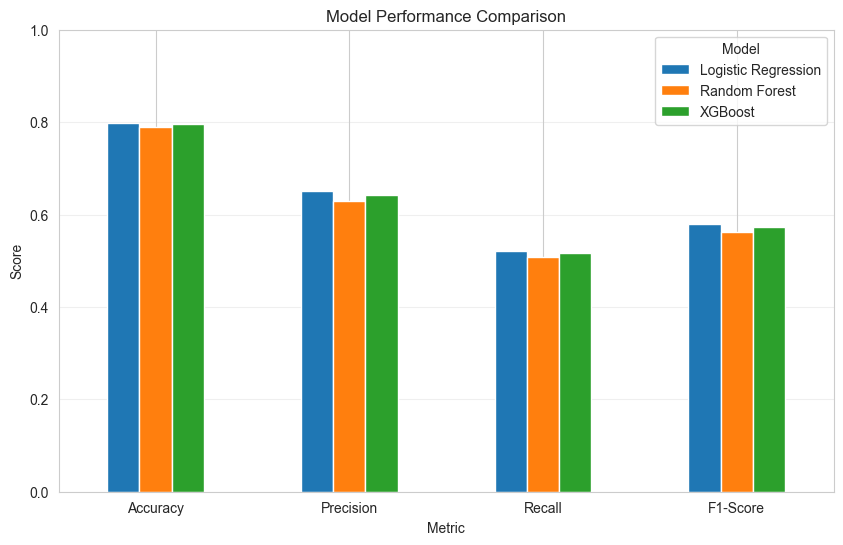

In [85]:
# Model Performance Comparison

model_comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Final Model Selection

Logistic Regression was selected as the final model because it achieved the best performance across the four threshold-based classification metrics: Accuracy, Precision, Recall and F1-Score. XGBoost achieved the highest ROC-AUC at 0.8443, slightly above Logistic Regression at 0.8423. Therefore, Logistic Regression was selected based on the overall threshold classification metrics and its interpretability.

- Accuracy: 79.84%
- Precision: 65.00%
- Recall: 52.14%
- F1-Score: 57.86%

Logistic Regression achieved slightly better results than XGBoost and Random Forest across all four evaluated metrics.

Its ROC-AUC of 0.8423 also indicates strong ability to distinguish between customers likely to churn and customers likely to remain.

The model can therefore be used as a customer-risk scoring tool to help prioritize retention efforts.

## SHAP Model Interpretation

In [86]:
# Check SHAP installation

import shap

print("SHAP version:", shap.__version__)

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [87]:
# Create SHAP explainer for Logistic Regression

explainer = shap.LinearExplainer(
    logistic_model,
    X_train_scaled
)

shap_values = explainer(X_test_scaled)

print("SHAP values calculated successfully.")

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP values calculated successfully.


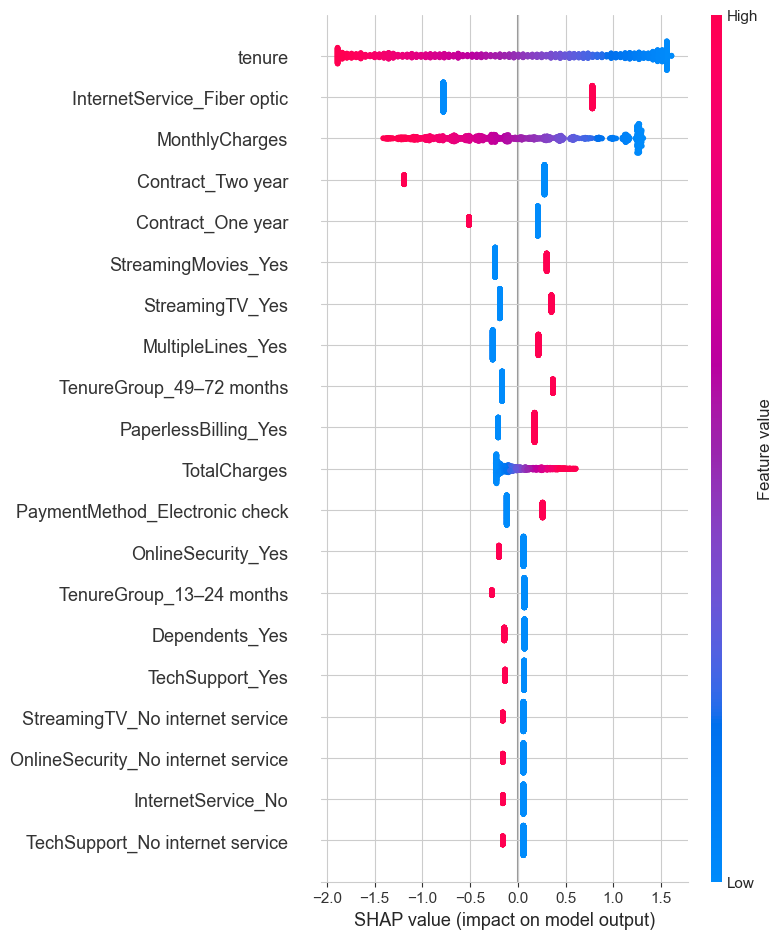

In [88]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

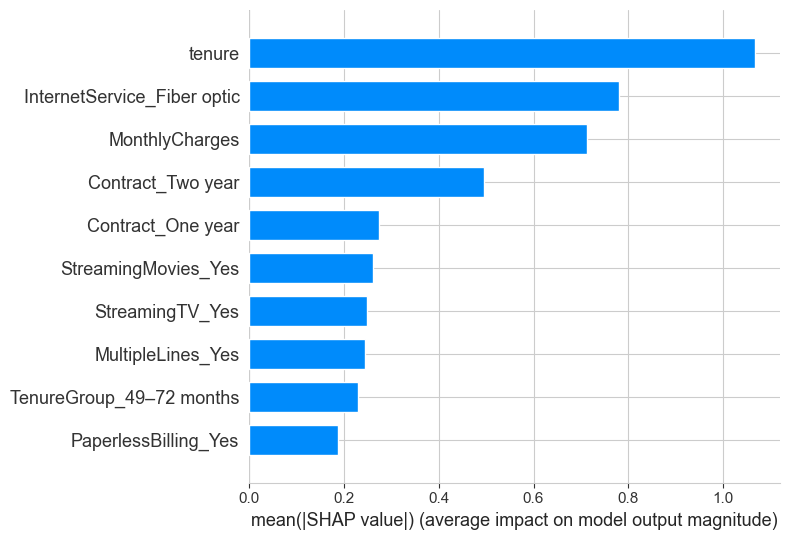

In [91]:
# SHAP Feature Importance

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    max_display=10
)

In [77]:
# Top 10 SHAP Features

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean Absolute SHAP": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
).head(10)

shap_importance

,Feature,Mean Absolute SHAP
1,tenure,1.066721
10,InternetService_Fiber optic,0.780011
2,MonthlyCharges,0.712616
25,Contract_Two year,0.496337
24,Contract_One year,0.273218
23,StreamingMovies_Yes,0.261670
21,StreamingTV_Yes,0.248304
9,MultipleLines_Yes,0.243378
32,TenureGroup_49–72 months,0.229191
26,PaperlessBilling_Yes,0.187470


In [88]:
shap_importance.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)

print("SHAP dataset created successfully.")

SHAP dataset created successfully.


## SHAP Interpretation

SHAP analysis shows that tenure, fiber-optic internet service, and monthly charges have the largest influence on the Logistic Regression model's churn predictions.

Lower tenure is associated with higher predicted churn risk, while longer tenure generally pushes predictions toward lower churn risk.

Fiber-optic internet service and higher monthly charges show meaningful contributions toward higher churn risk.

Contract type also has a strong influence on predictions. One-year and two-year contracts generally push predictions toward lower churn risk compared with the reference contract category.

Overall, the SHAP results reinforce the earlier exploratory analysis and indicate that customer tenure, service type, pricing, and contract structure are important factors in the model's churn predictions.

These relationships represent model associations rather than causal effects.

In [78]:
# Logistic Regression Coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Sort by coefficient
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
10,InternetService_Fiber optic,0.774509
21,StreamingTV_Yes,0.263656
23,StreamingMovies_Yes,0.263248
32,TenureGroup_49–72 months,0.247339
9,MultipleLines_Yes,0.236421
3,TotalCharges,0.225144
26,PaperlessBilling_Yes,0.187203
28,PaymentMethod_Electronic check,0.177309
17,DeviceProtection_Yes,0.066607
0,SeniorCitizen,0.056942


In [79]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability of churn
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.8423


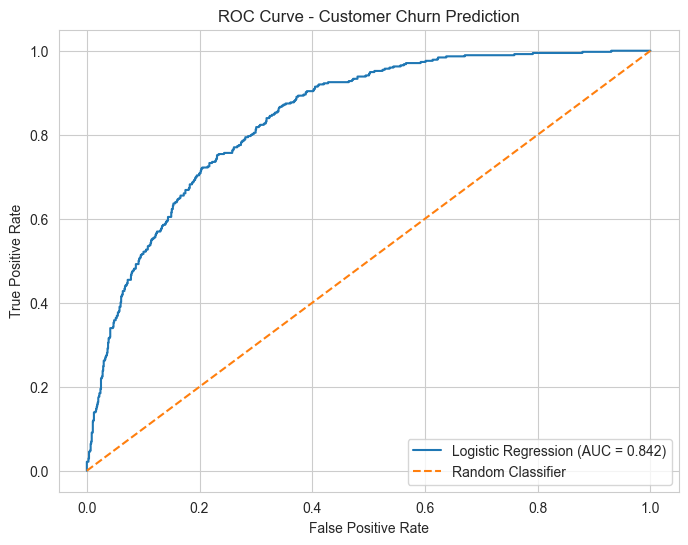

In [80]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()

plt.show()

## 8. Model Interpretation

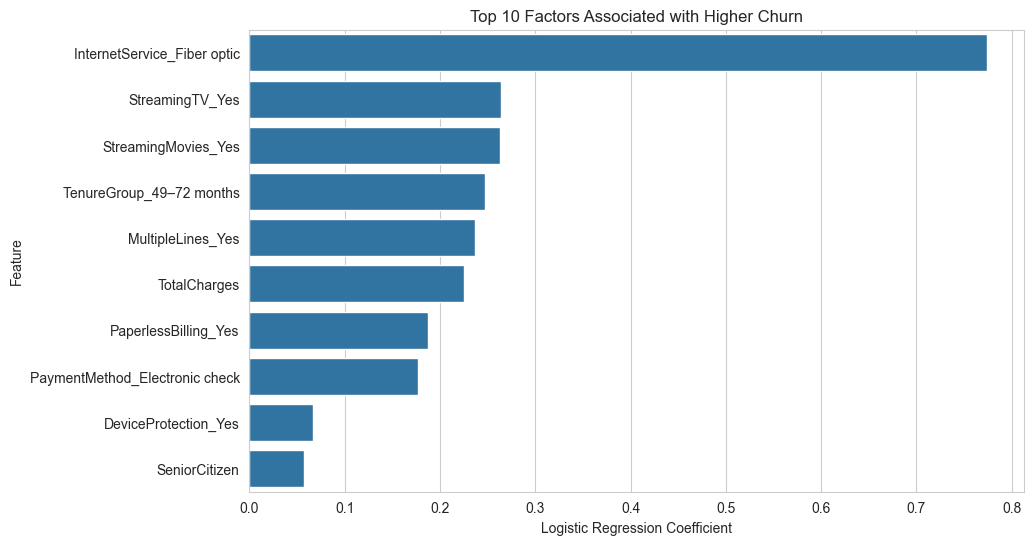

In [81]:
# Top 10 features increasing churn risk

top_positive = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Factors Associated with Higher Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

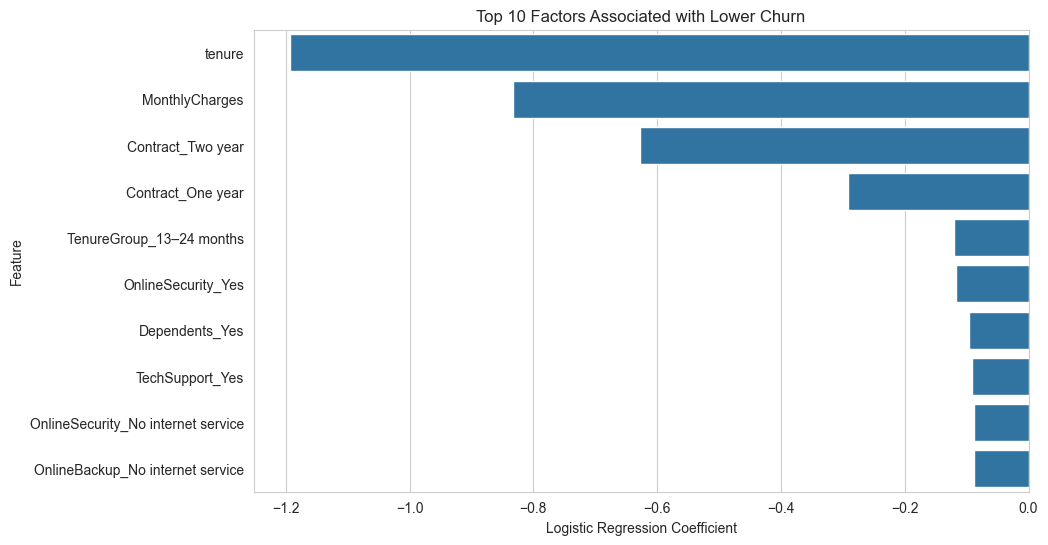

In [82]:
# Top 10 features associated with lower churn risk

top_negative = feature_importance.tail(10).sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Factors Associated with Lower Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

## 9. Business Insights and Recommendations

### Key Findings

1. Month-to-month contract customers have the highest churn rate, making them the highest-priority retention segment.

2. Customers with 0–12 months of tenure have the highest churn rate, indicating that the early customer lifecycle is a critical period for retention.

3. Electronic check customers have a substantially higher churn rate than customers using other payment methods.

4. Fiber optic customers show a high churn rate and should be investigated for possible service quality, pricing, or customer experience issues.

5. Customers on one-year and two-year contracts have significantly lower churn rates than month-to-month customers, suggesting that longer-term contracts are associated with greater customer retention.

6. Churned customers have higher median monthly charges than non-churned customers, indicating that pricing or perceived value may contribute to churn.

### Recommended Retention Strategies

- Target month-to-month customers with retention offers and incentives to move to longer-term contracts.
- Implement an early-life customer retention program for customers within their first 12 months.
- Investigate customer experience and service issues among fiber optic customers.
- Encourage customers using electronic checks to adopt alternative payment methods.
- Review pricing and perceived value for customers with higher monthly charges.
- Use the churn prediction model to identify high-risk customers and prioritize proactive retention campaigns.

## 10. Model Performance Summary

The Logistic Regression model achieved:

- Accuracy: 79.84%
- Precision: 65.00%
- Recall: 52.14%
- F1-Score: 57.86%
- ROC-AUC: 84.23%

Logistic Regression performed slightly better than XGBoost and Random Forest across all evaluated classification metrics. Its ROC-AUC of 0.8423 indicates strong ability to distinguish between customers likely to churn and customers likely to remain.

The model can therefore be used as a customer-risk scoring tool to help prioritize retention efforts.

# 11. Power BI Dashboard Data Preparation

In [83]:
# Prepare clean dataset for Power BI

powerbi_df = df.copy()

# Convert Churn back to business-friendly labels
powerbi_df["Churn"] = powerbi_df["Churn"].map({
    0: "No",
    1: "Yes"
})

# Save dataset for Power BI
powerbi_df.to_csv(
    "Customer_Churn_PowerBI.csv",
    index=False
)

print("Power BI dataset created successfully.")
print("Shape:", powerbi_df.shape)

Power BI dataset created successfully.
Shape: (7043, 22)


In [85]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities
lr_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# ROC-AUC scores
lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print("Logistic Regression ROC-AUC:", round(lr_auc, 4))
print("Random Forest ROC-AUC:", round(rf_auc, 4))
print("XGBoost ROC-AUC:", round(xgb_auc, 4))

Logistic Regression ROC-AUC: 0.8423
Random Forest ROC-AUC: 0.8251
XGBoost ROC-AUC: 0.8443


In [86]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7984,
        0.7899,
        0.7956
    ],
    "Precision": [
        0.6500,
        0.6291,
        0.6433
    ],
    "Recall": [
        0.5214,
        0.5080,
        0.5160
    ],
    "F1 Score": [
        0.5786,
        0.5621,
        0.5727
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc
    ]
})

model_results.to_csv(
    "Model_Performance.csv",
    index=False
)

print("Model_Performance.csv updated successfully.")
print(model_results)

Model_Performance.csv updated successfully.
                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0  Logistic Regression    0.7984     0.6500  0.5214    0.5786  0.842287
1        Random Forest    0.7899     0.6291  0.5080    0.5621  0.825132
2              XGBoost    0.7956     0.6433  0.5160    0.5727  0.844293


# 12. Final Conclusion

The analysis identified several customer segments associated with higher churn risk. The strongest patterns were observed among month-to-month contract customers, customers in their first 12 months of tenure, electronic check users, and fiber optic customers.

Longer contract durations were associated with substantially lower churn rates, while churned customers generally showed higher monthly charges than retained customers.

Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost.

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---:|---:|---:|
| Accuracy | 79.84% | 78.99% | 79.56% |
| Precision | 65.00% | 62.91% | 64.33% |
| Recall | 52.14% | 50.80% | 51.60% |
| F1-Score | 57.86% | 56.21% | 57.27% |

Logistic Regression performed slightly better than XGBoost and Random Forest across all four evaluated classification metrics. Its ROC-AUC of 0.8423 indicates strong ability to distinguish between customers who are more likely to churn and those who are likely to remain.

The model can therefore be used as a customer-risk scoring tool to help prioritize retention efforts.

## Key Business Recommendations

1. **Prioritize month-to-month customers** with targeted retention offers and incentives to move toward longer-term contracts.

2. **Focus on new customers** during their first 12 months, where churn risk is highest.

3. **Investigate fiber optic customer experience**, including service quality, pricing, and support issues.

4. **Review electronic check customers** and encourage alternative payment methods where appropriate.

5. **Review pricing and perceived value** for customers with higher monthly charges.

6. **Use the churn model as a risk-scoring tool** to identify high-risk customers and prioritize proactive retention campaigns.

## Business Impact

The analysis can help the business move from reactive customer retention to a more proactive approach by identifying customers who are more likely to churn and allowing retention resources to be focused on higher-risk segments.

## Project Limitations

- The model's recall of 52.14% means that a significant proportion of actual churners are not identified at the default classification threshold.
- Model coefficients indicate associations rather than causal relationships.
- Additional model tuning and threshold optimization could potentially improve churn detection.
- Business interventions should be validated through controlled experiments before being implemented broadly.

---

## Project Summary

**Dataset:** Telco Customer Churn  
**Objective:** Analyze customer churn drivers and build a predictive churn model  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  
**Best Model:** Logistic Regression  
**Accuracy:** 79.84%  
**ROC-AUC:** 84.23%

**Primary retention priorities:**  
Month-to-month contracts → New customers → Electronic check users → Fiber optic customers